In [ ]:
# string 操作

text = "```json 123456``` json```"

cleaned = text.strip("`")  # 只會去掉頭尾的
print(cleaned)

if cleaned.startswith("json"):
    cleaned = cleaned.replace("json", "", 1)  # 1 表示只替換一次 json，即出現在最左邊的 json
    cleaned = cleaned.strip()

print(cleaned)

json 123456``` json
123456``` json


# Example Code

## Installation

In [1]:
!pip install -Uq langgraph openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.1 MB/s eta 0:00:00


## Imports

In [2]:
from __future__ import annotations

import json
import os
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, END
from openai import OpenAI

## State 定義

In [26]:
# ============================================================
# 1. State 定義（工程語意版本）
# ============================================================

class ReflectionState(TypedDict, total=False):
    draft_text: str          # 原始輸入草稿（自然語言）
    email_body: str          # 郵件正文內容（不是 email address）
    review_notes: str        # 審稿 / 反思建議
    needs_revision: bool    # 是否需要進一步修正
    iter: int               # 目前反思迭代次數
    max_iters: int          # 最大允許迭代次數

## OpenAI client 與 LLM 呼叫封裝

In [27]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')

client = OpenAI(api_key=OPENAI_API_KEY)

def llm_text(prompt: str) -> str:
    """
    單純回傳 LLM 輸出的文字內容。
    語意上：這裡『只產生文字，不賦予業務角色』
    """
    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
    )

    return response.output_text.strip()

## Generate 節點

In [28]:
# 輸入草稿，產生第一版郵件
# 輸出第一版郵件與 iter（初始化為 0）

def generate_node(state: ReflectionState) -> ReflectionState:
    """
    根據 draft_text 生成第一版商務郵件正文
    """
    prompt = (
        "你是專業的商務郵件助理。\n"
        "請將以下草稿改寫為正式、清楚、禮貌的商務郵件正文。\n"
        "若資訊不足，請用中性措辭保留彈性。\n\n"
        f"草稿內容：\n{state['draft_text']}"
    )

    generated_body = llm_text(prompt)

    return {
        "email_body": generated_body,
        "iter": state.get("iter", 0),
    }

## 審核（Reflection）節點

In [29]:
# 審核郵件的語氣、結構、資訊量
# 輸入：前一版郵件內容
# 輸出：needs_revision: bool / review_notes

def reflect_node(state: ReflectionState) -> ReflectionState:
    """
    檢查郵件正文品質，並用 JSON 回傳是否需要修正
    """
    prompt = (
        "你是嚴格的商務郵件審稿者。\n"
        "請檢查以下郵件正文是否有：\n"
        "- 語氣不夠正式\n"
        "- 結構不清楚\n"
        "- 資訊不足（時間、對象、目的）\n\n"
        "請只用 JSON 回覆（不要加任何說明文字）：\n"
        "{\n"
        '  "needs_revision": true/false,\n'
        '  "review_notes": "具體修改建議或通過理由"\n'
        "}\n\n"
        f"郵件正文：\n{state['email_body']}"
    )

    raw_output = llm_text(prompt)

    # 嘗試解析 JSON（處理模型偶爾包 ```json 的情況）
    cleaned = raw_output.strip().strip("`")
    if cleaned.lower().startswith("json"):
        cleaned = cleaned.replace("json", "", 1)  # 1 表示只替換一次 json，即出現在最左邊的 json
        cleaned = cleaned.strip()

    # 依 state 契約，轉為可輸出格式
    try:
        parsed = json.loads(cleaned)
        needs_revision = bool(parsed.get("needs_revision", False))
        review_notes = str(parsed.get("review_notes", "")).strip()
    except Exception:
        # 保守策略：解析失敗就視為需要修正
        needs_revision = True
        review_notes = f"JSON 解析失敗，模型輸出如下：{raw_output[:200]}"

    # Partially update the state
    return {
        "needs_revision": needs_revision,
        "review_notes": review_notes,
    }


## Update 節點

In [30]:
def update_node(state: ReflectionState) -> ReflectionState:
    """
    根據審稿建議修正郵件正文
    """
    prompt = (
        "請根據以下修改建議，修正郵件正文內容。\n"
        "請只輸出修正後的完整郵件正文，不要附加說明。\n\n"
        f"修改建議：\n{state['review_notes']}\n\n"
        f"原郵件正文：\n{state['email_body']}"
    )

    revised_body = llm_text(prompt)

    return {
        "email_body": revised_body,
        "iter": state.get("iter", 0) + 1,
    }

## Conditional Routing

In [31]:
def route_after_reflection(state: ReflectionState) -> Literal["update", "end"]:
    current_iter = state.get("iter", 0)
    max_iters = state.get("max_iters", 2)
    needs_revision = state.get("needs_revision", False)

    print(
        f"[ROUTE] iter={current_iter}, "
        f"max_iters={max_iters}, "
        f"needs_revision={needs_revision}"
    )

    if current_iter >= max_iters:
        return "end"

    if needs_revision:
        return "update"

    return "end"


## Graph 組裝

In [32]:
workflow = StateGraph(ReflectionState)

workflow.add_node("generate", generate_node)
workflow.add_node("reflect", reflect_node)
workflow.add_node("update", update_node)

workflow.set_entry_point("generate")

workflow.add_edge("generate", "reflect")
workflow.add_conditional_edges(
    "reflect",
    route_after_reflection,
    {
        "update": "update",
        "end": END,
    },
)
workflow.add_edge("update", "reflect")

graph = workflow.compile()

## 執行

In [33]:
if __name__ == "__main__":
    initial_state: ReflectionState = {
        "draft_text": "嗨，明天可以開會嗎？",
        "iter": 0,
        "max_iters": 2,
    }

    result = graph.invoke(
        initial_state,
        config={"recursion_limit": 10}
    )

    print("====== 最終郵件正文 ======")
    print(result["email_body"])
    print("\n====== 最後一次審稿意見 ======")
    print(result.get("review_notes", ""))


[ROUTE] iter=0, max_iters=2, needs_revision=True
[ROUTE] iter=1, max_iters=2, needs_revision=True
[ROUTE] iter=2, max_iters=2, needs_revision=True
====== 最終郵件正文 ======
尊敬的[對方姓名]先生/女士：

您好！

謹此邀請您參加於2024年6月15日（星期四）下午2時至3時，通過線上視訊形式舉行的專案進度討論會議。此次會議旨在檢視目前專案執行情況，交流合作細節，並討論後續計劃安排，預計時長約為一小時。

敬請您確認上述時間是否方便參與，並煩請回覆適合的具體時間段及將參加會議的相關人員姓名。

期待您的回复，感謝您的配合。

此致  
敬禮

[您的姓名]  
[您的職稱]  
[您的聯絡方式]

====== 最後一次審稿意見 ======
語氣基本正式，但可略微調整以增強商務禮貌，例如開頭可避免使用「您好！」並改為更正式的問候語。結構清晰，但請注意會議時長表達不一致，正文說下午2時至3時約一小時，但實際僅一小時，建議明確表述會議具體時間。資訊不足方面，應明確說明邀請對象的完整稱謂與職位，並補充會議平台及連結或如何獲取連結。此外，請求回覆時建議限定回覆期限以利安排。最後，聯絡方式應詳細，包括電話及電郵。


# Graph Diagram

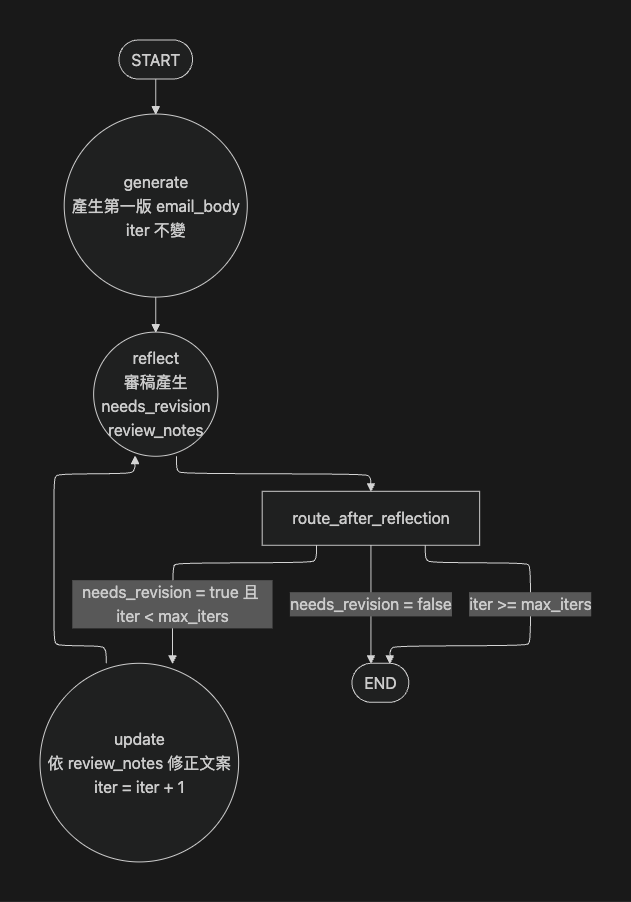